# TELECOM PARTE 2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ayelen95/Challenge_Parte-2/blob/main/Telecom_parte2_dao.ipynb)

# 📌 EXTRACCIÓN

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Se carga archivo CSV que contiene los datos tratados: " datos_tratados.csv "

In [3]:
rutas = '/content/datos_tratados.csv'

In [4]:
df = pd.read_csv(rutas)
df.head(2)

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.3
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.4


In [5]:
df.shape

(7043, 22)

Verifica valores NaNs y vacíos

In [6]:
for column in df.columns:
    # 1. Detectar NaN (Nulos reales)
    nulos = df[column].isnull().sum()
    # 2. Contar vacíos 
    vacios = 0
    if df[column].dtype == 'object':
        # Usamos strip() para contar también celdas con solo espacios ' ' como vacías
        vacios = (df[column].astype(str).str.strip() == '').sum()
        
    if nulos > 0 or vacios > 0:
        print(f'{column}: {nulos} NaNs, {vacios} strings vacíos/blancos')

Muestra valores únicos de las columnas 'object'

In [7]:

for col in df.select_dtypes(include='object').columns:  
    print('-'*40)
    print(f'Columna: {col} (Tiene {df[col].nunique()} valores únicos)')# Muestra el nombre y cuántos valores únicos tiene
    if df[col].nunique() < 20:
        print(df[col].unique())
    else:
        print("Demasiados valores únicos para mostrar (posiblemente nombres o IDs).")

----------------------------------------
Columna: CustomerID (Tiene 7043 valores únicos)
Demasiados valores únicos para mostrar (posiblemente nombres o IDs).
----------------------------------------
Columna: Churn (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: Gender (Tiene 2 valores únicos)
['Female' 'Male']
----------------------------------------
Columna: SeniorCitizen (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: Partner (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: Dependents (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: PhoneService (Tiene 2 valores únicos)
['Yes' 'No']
----------------------------------------
Columna: MultipleLines (Tiene 2 valores únicos)
['No' 'Yes']
----------------------------------------
Columna: InternetService (Tiene 3 valores únicos)
['DSL' 'Fiber optic' 'No']
------------------------------

Información de columnas y dataset

In [8]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


# 🛠️ Pre procesamiento

Eliminación de columnas irrelevantes:

In [10]:
# Eliminamos el id, no necesitamos para esta parte (muchos valores)
df = df.drop(columns=['CustomerID'])

In [11]:
df.tail(3)

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65
7042,No,Male,No,Yes,Yes,63,No,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Electronic check,1.97,59.00,3707.60


Se reemplazo valores de 'No internet service' por valor 'No' en las variables 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'


In [12]:
# Multicolinealidad
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in cols_to_fix:
    df[col] = df[col].replace({'No internet service': 'No'})

In [13]:
# Verificamos valores nulos:
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# 📊 EDA

## Correlación entre variables númericas

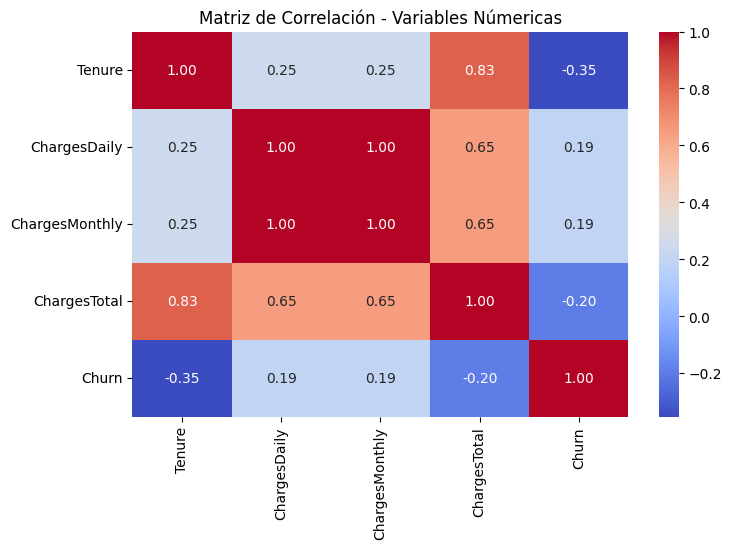

In [14]:
# Para hacer uso de la matriz correlacion se debe utilizar valores de tipo númericos
df_numeric = df.select_dtypes(include=['int64', "float64"])
df_numeric['Churn'] = df['Churn'].map({"Yes":1, "No":0})

corr_matrix = df_numeric.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Variables Númericas")
plt.show()

* Se presenta autocorrelación, ver variables **ChargesDaily** y **ChargesMontly** son la misma variables. Es redundate, se opta por dejar la variable **ChargesMontly**.


* Otra situación que se visualiza entre las variables **Tenure** y **ChargesTotal**, nos quedamos con variable **Tenure**


* Eliminacion de variables **ChargesDaily** y **ChargesTotal**

In [15]:
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

## Asociación entre variables categóricas (Test de Chi-Cuadrado)

Anáĺisis de Churn por categoría (Variables categóricas)

### Seleccionar variables categóricas

In [16]:
# Creamos df temporal para ver las variables categóricas que tienen similitud con Churn
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Churn')

### 1ra Manera - Tabla de proporción por categoria

In [17]:
for col in categorical_cols:
    print(f"\n Análisis de variable: {col}")
    display(pd.crosstab(df[col], df["Churn"], normalize="index")*100)


 Análisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



 Análisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



 Análisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



 Análisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



 Análisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


### 2da Manera - Método del CHI - CUADRADO ( $\chi^2$ )

El método anterior, toma tiempo y si fuesen 50 variables?

Se utiliza el método del Chi-cuadrado ( $\chi^2$ )

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

In [19]:
# Se crea copia df
df_rank = df.copy()

df_rank['Churn'] = df_rank['Churn'].map({"Yes":1, "No": 0})

# Separar variables categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporario
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar x e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar test Chi-cuadrado
chi_scores, p_values = chi2(X_cat, y)

# Crear DataFrame con ranking
chi_df = pd.DataFrame({
    "Variable": categorical_cols,
    "Chi2 Score": chi_scores, # valor de similitud
    "p_value": p_values # valor de confianza(%)
})

# Ordenar por importancia
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df

,Variable,Chi2 Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


In [20]:
significant_vars = chi_df[chi_df["p_value"] < 0.05]


print("\n Variables significativas (p < 0.05): ")
display(significant_vars)


 Variables significativas (p < 0.05): 


,Variable,Chi2 Score,p_value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


Se observa en el dataframe significant_vars temporal que las variables **Gender** y **PhoneService** se puede eliminar. 

In [21]:
df = df.drop(columns =["Gender","PhoneService"])

# 🎯 Split

## Split del dataset

In [22]:
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"Yes":1, "No":0})

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y, # desbalanceo
    random_state=42
)

#stratify=y mantiene el mismo balance de churn.

## ONE-HOT ENCODING

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning.



In [25]:
# Aplicar One-Hot Encoding en entrenamiento
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar One-Hot Encoding en test
X_test = pd.get_dummies(X_test, drop_first= True)

# Asegurar que entrenamiento y test tengan las mismas columnas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [26]:
X_train.head(3)

,Tenure,ChargesMonthly,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3793,60,94.10,False,True,False,True,True,False,True,True,False,False,False,True,False,False,True,True,False,False
3192,12,19.35,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False
4922,2,80.45,False,False,False,False,True,False,True,False,True,False,False,False,False,False,True,False,True,False


## Aplicar SMOTE 

In [27]:
from imblearn.over_sampling import SMOTE

In [28]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# SMOTE SOLO en entrenamiento

Verificación de la Proporción de Cancelación (Churn)

Se calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Existe un desbalance entre las clases y esto puede impactar en los modelos predictivos y en el análisis de los resultados.



In [29]:
y_train.value_counts(normalize=True)*100

,proportion
Churn,
0,73.464679
1,26.535321


## Análisis de variables más correlacionadas con **Churn**.

Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

In [30]:
df_encoded = df.copy()
df_encoded = pd.get_dummies(df_encoded, drop_first=True)

In [35]:
corr_matrix_analisis = df_encoded.corr()

corr_matrix_analisis["Churn_Yes"].sort_values(ascending=False).head(10)

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.308020
PaymentMethod_Electronic check,0.301919
ChargesMonthly,0.193356
PaperlessBilling_Yes,0.191825
SeniorCitizen_Yes,0.150889
StreamingTV_Yes,0.063228
StreamingMovies_Yes,0.061382
MultipleLines_Yes,0.040102
DeviceProtection_Yes,-0.066160


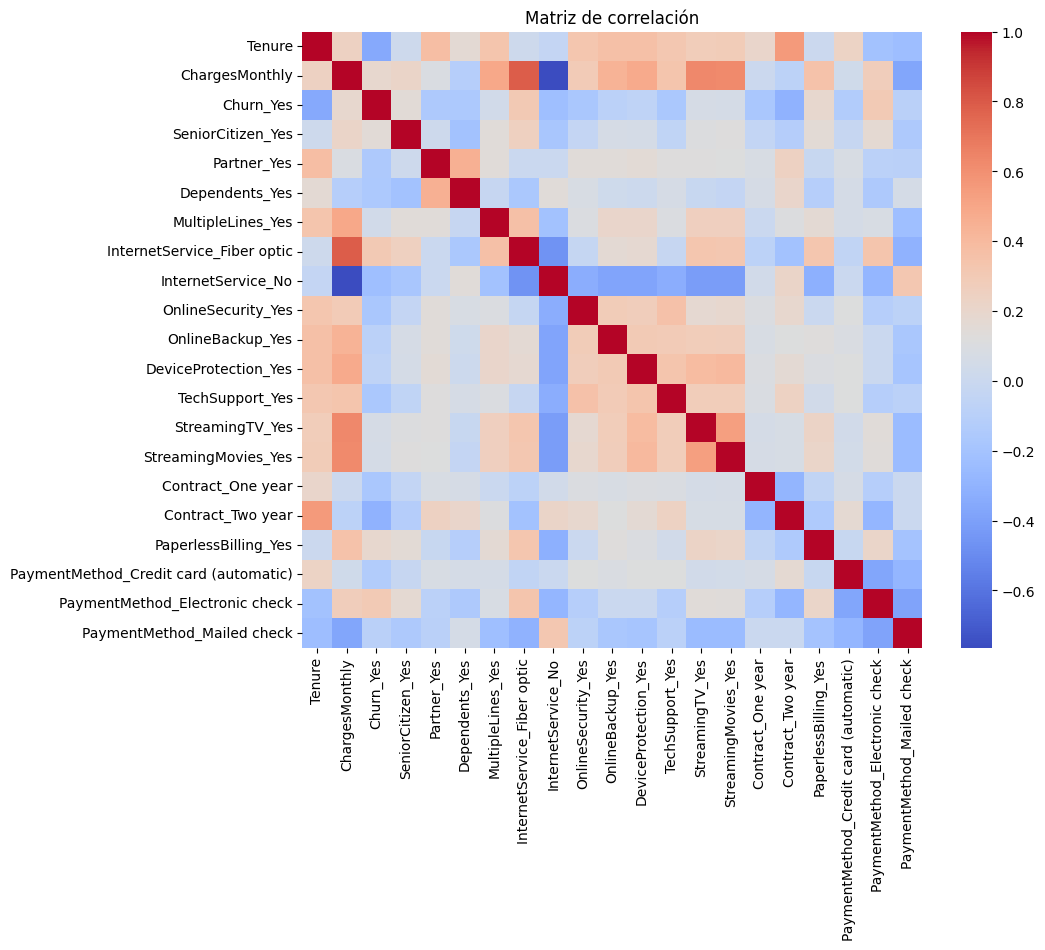

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación")
plt.show()

Interpretación de la matriz de correlación

Se generó una matriz de correlación para identificar posibles relaciones entre las variables del dataset. Sin embargo, debido a la aplicación de **One-Hot Encoding**, el número de variables aumenta considerablemente, lo que produce una matriz extensa y difícil de interpretar visualmente.



## Análisis Dirigido

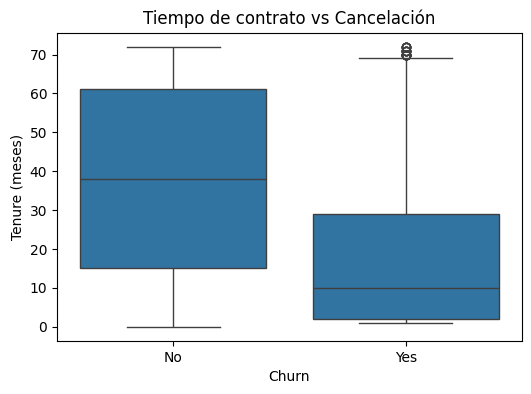

In [45]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="Tenure",
    data=df
)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Tenure (meses)")

plt.show()

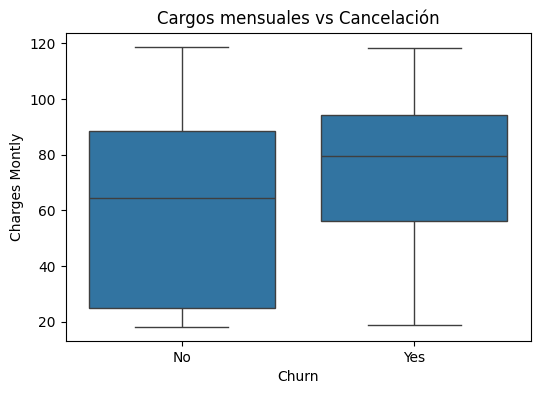

In [46]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Churn",
    y="ChargesMonthly",
    data=df
)

plt.title("Cargos mensuales vs Cancelación")
plt.xlabel("Churn")
plt.ylabel("Charges Montly")

plt.show()

# 🧠 Entrenamiento

Definir los modelos

In [47]:
# librerias técnicas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
# Metricas
from sklearn.metrics import classification_report, roc_curve, roc_auc_score, accuracy_score, precision_score,recall_score, f1_score

In [48]:
models_normal = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_estimators=200),
    "SVM": SVC(probability=True)
}

In [49]:
models_balanced = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=200, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_estimators=200, class_weight="balanced"),
    "SVM": SVC(probability=True, class_weight="balanced")
}

In [50]:
resultados_metricas = []
resultados_roc = []

In [51]:
def evaluar_modelos(models, X_train, y_train, nombre_enfoque):

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1] # dato que me ayuda para la curva ROC

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        resultados_metricas.append({
            "Modelo": name,
            "Enfoque": nombre_enfoque,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-score": f1,
            "ROC-AUC": auc
        })

        fpr, tpr, _ = roc_curve(y_test, y_prob)

        resultados_roc.append({
            "Modelo": name,
            "Enfoque": nombre_enfoque,
            "FPR": fpr,
            "TPR": tpr,
            "AUC": auc
        })

In [52]:
evaluar_modelos(models_normal, X_train, y_train, "Normal")

evaluar_modelos(models_balanced, X_train, y_train, "Class_weight")

evaluar_modelos(models_normal, X_train_smote, y_train_smote, "SMOTE")

# 📈 Evaluación

In [53]:
tabla_resultados = pd.DataFrame(resultados_metricas)

tabla_resultados = tabla_resultados.sort_values(
    by="ROC-AUC",
    ascending=False
)

tabla_resultados

,Modelo,Enfoque,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,GradientBoosting,Normal,0.796309,0.646465,0.513369,0.572280,0.846616
7,GradientBoosting,Class_weight,0.796309,0.646465,0.513369,0.572280,0.846616
5,LogisticRegression,Class_weight,0.743080,0.510417,0.786096,0.618947,0.842587
0,LogisticRegression,Normal,0.798439,0.649007,0.524064,0.579882,0.842202
12,GradientBoosting,SMOTE,0.775018,0.561290,0.697861,0.622169,0.835364
1,RandomForest,Normal,0.782825,0.618056,0.475936,0.537764,0.821470
6,RandomForest,Class_weight,0.785664,0.627660,0.473262,0.539634,0.818032
14,SVM,SMOTE,0.721079,0.484140,0.775401,0.596095,0.817039
9,SVM,Class_weight,0.711143,0.472081,0.745989,0.578238,0.815978
10,LogisticRegression,SMOTE,0.748758,0.521552,0.647059,0.577566,0.814728


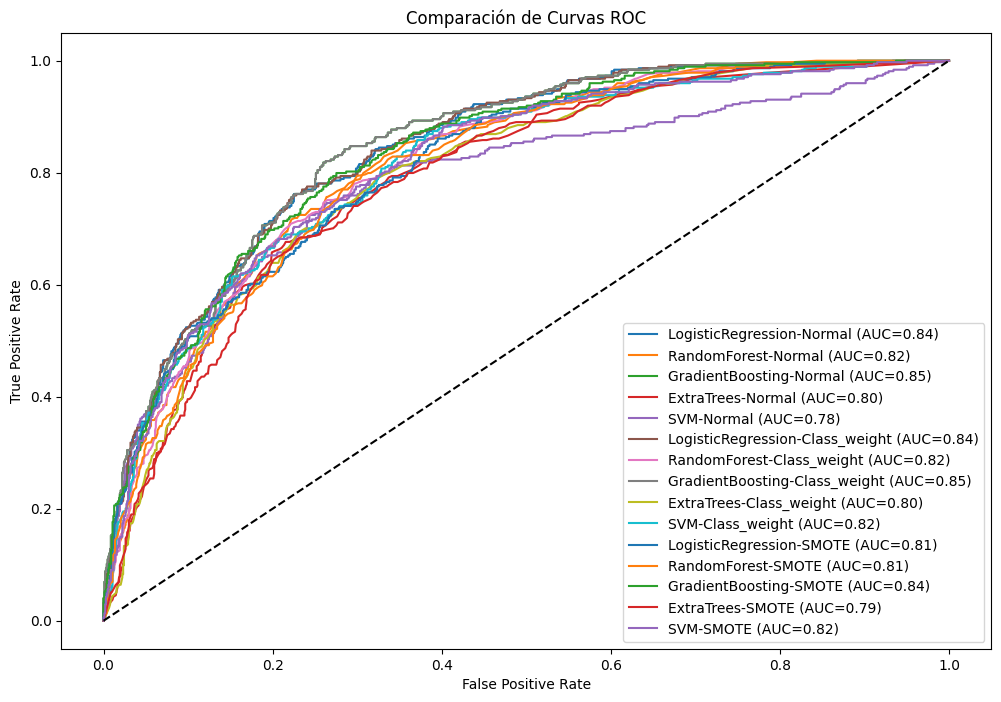

In [54]:
plt.figure(figsize=(12,8))

for roc in resultados_roc:

    plt.plot(
        roc["FPR"],
        roc["TPR"],
        label=f'{roc["Modelo"]}-{roc["Enfoque"]} (AUC={roc["AUC"]:.2f})'
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC")
plt.legend()
plt.show()

In [55]:
tabla_resultados.head(5)

,Modelo,Enfoque,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,GradientBoosting,Normal,0.796309,0.646465,0.513369,0.572280,0.846616
7,GradientBoosting,Class_weight,0.796309,0.646465,0.513369,0.572280,0.846616
5,LogisticRegression,Class_weight,0.743080,0.510417,0.786096,0.618947,0.842587
0,LogisticRegression,Normal,0.798439,0.649007,0.524064,0.579882,0.842202
12,GradientBoosting,SMOTE,0.775018,0.561290,0.697861,0.622169,0.835364


In [56]:
modelos_base = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42, n_estimators=200),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, n_estimators=200),
    "SVM": SVC(probability=True)
}


In [57]:


from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def matriz_confusion_top(tabla):

    for _, row in tabla.iterrows():

        modelo = modelos_base[row["Modelo"]]

        if row["Enfoque"] == "Class_weight":
            if row["Modelo"] in ["LogisticRegression","RandomForest","ExtraTrees","SVM"]:
                modelo.set_params(class_weight="balanced")

        # elegir dataset
        if row["Enfoque"] == "SMOTE":
            Xtr, ytr = X_train_smote, y_train_smote
        else:
            Xtr, ytr = X_train, y_train

        modelo.fit(Xtr, ytr)

        y_pred = modelo.predict(X_test)

        ConfusionMatrixDisplay.from_predictions(
            y_test,
            y_pred
        )

        plt.title(f'{row["Modelo"]} - {row["Enfoque"]}')
        plt.xticks([0,1], ["No", "Yes"])
        plt.yticks([0,1], ["No", "Yes"])
        plt.show()

In [58]:
top5 = tabla_resultados.head(5)
top5

,Modelo,Enfoque,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,GradientBoosting,Normal,0.796309,0.646465,0.513369,0.572280,0.846616
7,GradientBoosting,Class_weight,0.796309,0.646465,0.513369,0.572280,0.846616
5,LogisticRegression,Class_weight,0.743080,0.510417,0.786096,0.618947,0.842587
0,LogisticRegression,Normal,0.798439,0.649007,0.524064,0.579882,0.842202
12,GradientBoosting,SMOTE,0.775018,0.561290,0.697861,0.622169,0.835364


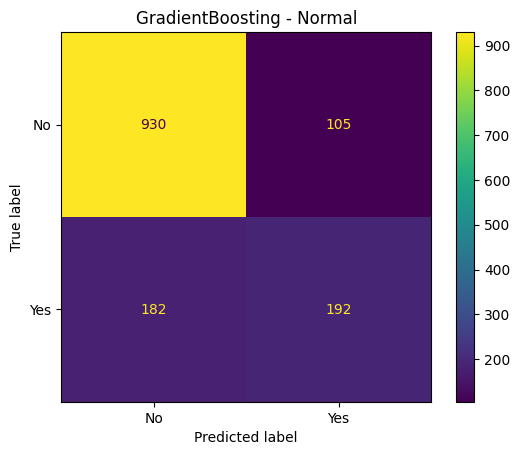

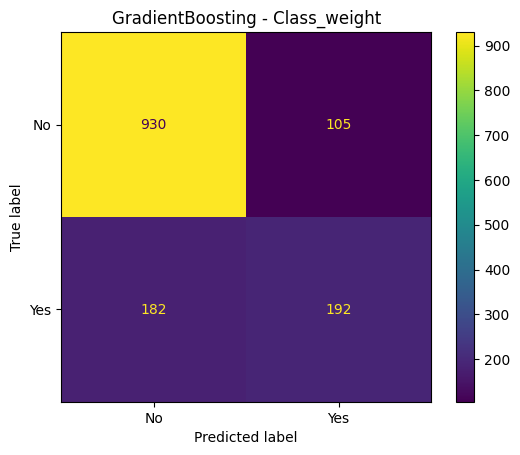

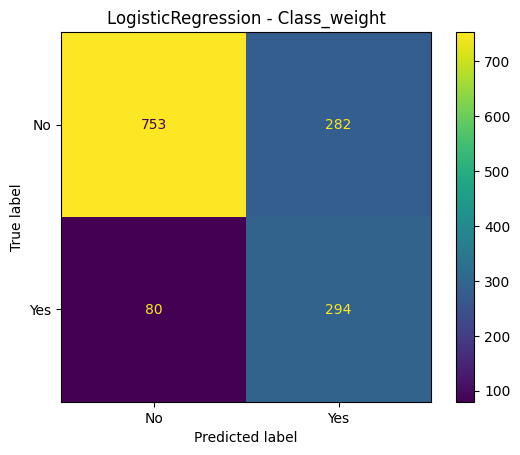

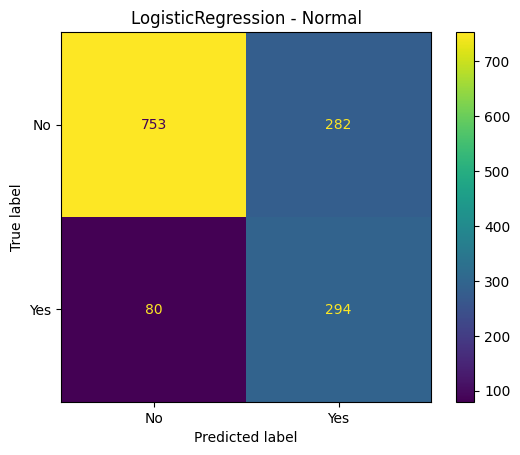

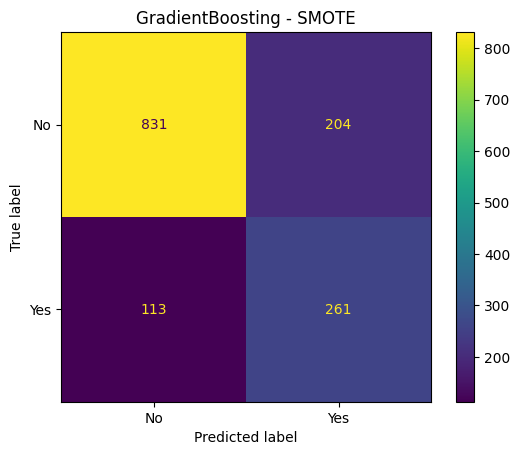

In [59]:
matriz_confusion_top(top5)

# 📄 INFORME FINAL

## 📈 Predicción de Abandono de Clientes (Churn)

## 🎯 Objetivo:
---
El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes y evaluar diferentes modelos de clasificación para predecir el **Churn** (abandono del servicio).

Se compararon distintos algoritmos de Logistic Regression, Random Forest, Gradient Boosting, Extra Trees y Support Vector Machine aplicando tres enfoques:

* modelos normales

* modelos con class_weight="balanced"

* modelos entrenados con SMOTE

La evaluación se realizó utilizando métricas como **Accuracy, Precision, Recall, F1-score y ROC-AUC**, además de analizar la **Confusion Matrix** de los modelos con mejor rendimiento.


## 🔍 Factores que influyen en la cancelación:
---
A partir del análisis exploratorio (EDA) y la correlación entre variables se identificaron:

* Antigüedad del cliente (Tenure)

Se observó que los clientes con menor tiempo de permanencia presentan mayor probabilidad de cancelar el servicio. Esto sugiere que los primeros meses del cliente son críticos para su retención.


<p align="center">
  <img src="images/boxplot1.png" width="400" alt="Tiempos de Contrato VS Cancelación">
</p>

* Tipo de contrato

Los clientes con contratos mensuales presentan mayores tasas de cancelación en comparación con aquellos con contratos de uno o dos años, lo que indica que los contratos de mayor duración ayudan a reducir el churn.

* Cargos mensuales

El análisis de ChargesMonthly muestra que los clientes con cargos mensuales más elevados tienden a presentar una mayor probabilidad de cancelación, posiblemente debido a la percepción de costos elevados.

<p align="center">
    <img src="images/boxplot2.png" width="400" alt="Cargas Mensuales VS Cancelación">
<p>

* Servicios adicionales

Variables relacionadas con servicios como TechSupport, OnlineSecurity o DeviceProtection muestran correlaciones negativas con churn, lo que sugiere que los clientes que utilizan más servicios tienden a permanecer más tiempo en la empresa.


## 📊 4. Evaluación y Resultados
---
A continuación se presentan los resultados de los modelos evaluados, destacando sus métricas más relevantes bajo diferentes enfoques de manejo de desbalanceo:

| Modelo               | Enfoque          | Característica Destacada   | Accuracy   | Precision  | Recall     | F1-Score   | ROC-AUC   |
|:--------------------:|:----------------:|:--------------------------:|:----------:|:----------:|:----------:|:----------:|:---------:|
| 🏆 Gradient Boosting | Normal           | Mejor **ROC-AUC**          | 0.7963     | 0.6465     | 0.5134     | 0.5723     | **0.8466**|
| 🎯 Logistic Regression | Class Weight   | Mejor **Recall**           | 0.7431     | 0.5104     | **0.7861** | 0.6189     | 0.8426    |
| ⚖️ Gradient Boosting | SMOTE            | Buen equilibrio            | 0.7750     | 0.5613     | 0.6979     | **0.6222** | 0.8354    |

En cuanto al rendimiento de los modelos, **Gradient Boosting** obtuvo el mejor desempeño general en términos de ROC-AUC, mientras que **Logistic Regression** con class_weight logró detectar una mayor proporción de clientes que cancelan (mayor recall). Por su parte, **Gradient Boosting** con **SMOTE** mostró un buen equilibrio entre precisión y detección de churn.

### Matriz de Confusión y Métricas Clave

<p align="center">
    <img src="images/rl_1.png" width="400" alt="Matriz Confusion">
<p>

<p align="center">
    <img src="images/gb_1.png" width="400" alt="Matriz Confusion">
<p>

- **Logistic Regression:** Logró un Recall del **0.79**, logrando detectar a **80** clientes en riesgo de fuga.
- **Gradient Boosting:** Alcanzó un Recall del **0.51**, detectando a **105** clientes.

## 💡 5. Modelo recomendado
---


En este análisis, el modelo de **Logistic Regression con class_weight** mostró un mejor desempeño en términos de recall, lo que indica una mayor capacidad para detectar clientes que cancelan el servicio, aunque a costa de generar más falsos positivos. Esto puede resultar útil en escenarios donde la empresa prefiere identificar la mayor cantidad posible de clientes en riesgo para aplicar estrategias de retención.

Por otro lado, el modelo **Gradient Boosting** obtuvo el mejor desempeño general en términos de ROC-AUC, mostrando una buena capacidad de discriminación entre clientes que cancelan y los que permanecen.


**Conclusión:** Considerando estos resultados, una estrategia razonable sería utilizar **Gradient Boosting** como modelo principal por su desempeño general, mientras que **Logistic Regression con class_weight** puede resultar útil cuando el objetivo sea priorizar la detección de clientes con riesgo de abandono.